In [1]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
dataframe = pd.read_csv("D:\practice_misc\Zomato-data-.csv")
print(dataframe.head())

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Aditi Tatkare\AppData\Local\Temp\ipykernel_13732\2620237843.py:1: SyntaxWarning: invalid escape sequence '\p'
  dataframe = pd.read_csv("D:\practice_misc\Zomato-data-.csv")


                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [4]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())


                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'Type of restaurant')

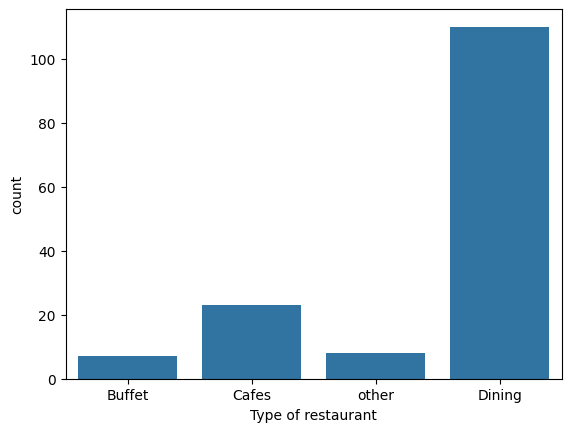

In [6]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")

Text(0, 0.5, 'votes')

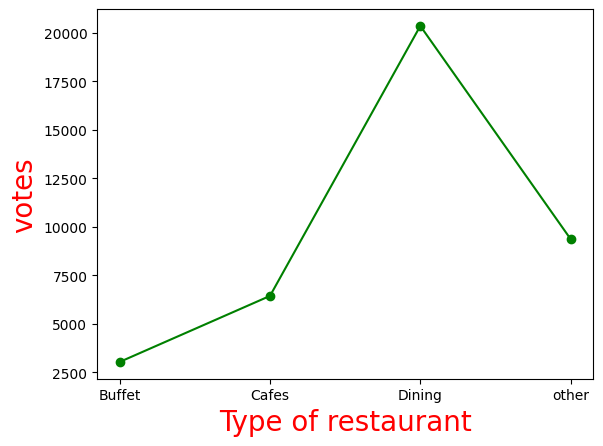

In [7]:
grouped_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_data})
plt.plot(result,c='green',marker='o')
plt.xlabel('Type of restaurant',c='red',size=20)
plt.ylabel('votes',c='red', size=20)

In [8]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes']== max_votes,'name']

print("Restaurants with maximum votes:")
print(restaurant_with_max_votes)

Restaurants with maximum votes:
38    Empire Restaurant
Name: name, dtype: object


<Axes: xlabel='online_order', ylabel='count'>

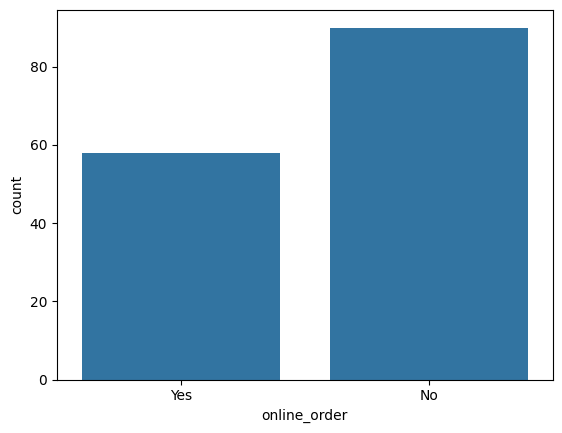

In [9]:
sns.countplot(x=dataframe['online_order'])

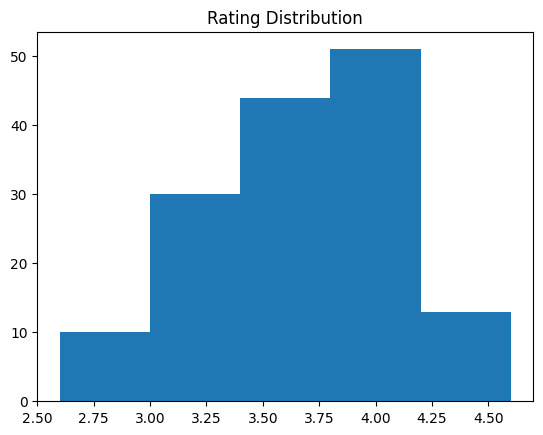

In [10]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Rating Distribution')
plt.show()

In [16]:
import pandas as pd

# Assuming dataframe is already loaded

# 1. Online delivery flag
if 'online_order' in dataframe.columns:
    dataframe['online_delivery_flag'] = dataframe['online_order'].map({'Yes': 1, 'No': 0})

# 2. Book table flag
if 'book_table' in dataframe.columns:
    dataframe['book_table_flag'] = dataframe['book_table'].map({'Yes': 1, 'No': 0})

# 3. Clean ratings
# Some ratings might be 'NEW' or '-', convert those to NaN
dataframe['rate'] = pd.to_numeric(
    dataframe['rate'].apply(lambda x: str(x).split('/')[0] if str(x).replace('.','',1).isdigit() else None),
    errors='coerce'
)

# 4. Rating categories
dataframe['rating_category'] = pd.cut(
    dataframe['rate'],
    bins=[0, 2.5, 3.5, 4.5, 5],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

max_cost = dataframe['cost_per_person'].max()

# Define bins dynamically
bins = [0, 200, 500, 1000, 2000]

# Ensure last bin covers the max value
if max_cost > 2000:
    bins.append(max_cost)
else:
    bins.append(2000)





In [17]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),cost_per_person,online_delivery_flag,book_table_flag,rating_category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,400.0,1,1,Good
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,400.0,1,0,Good
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,400.0,1,0,Good
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,150.0,0,0,Good
4,Grand Village,No,No,3.8,166,600,Buffet,300.0,0,0,Good


In [13]:
print(dataframe.columns.tolist())


['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)', 'cost_per_person']


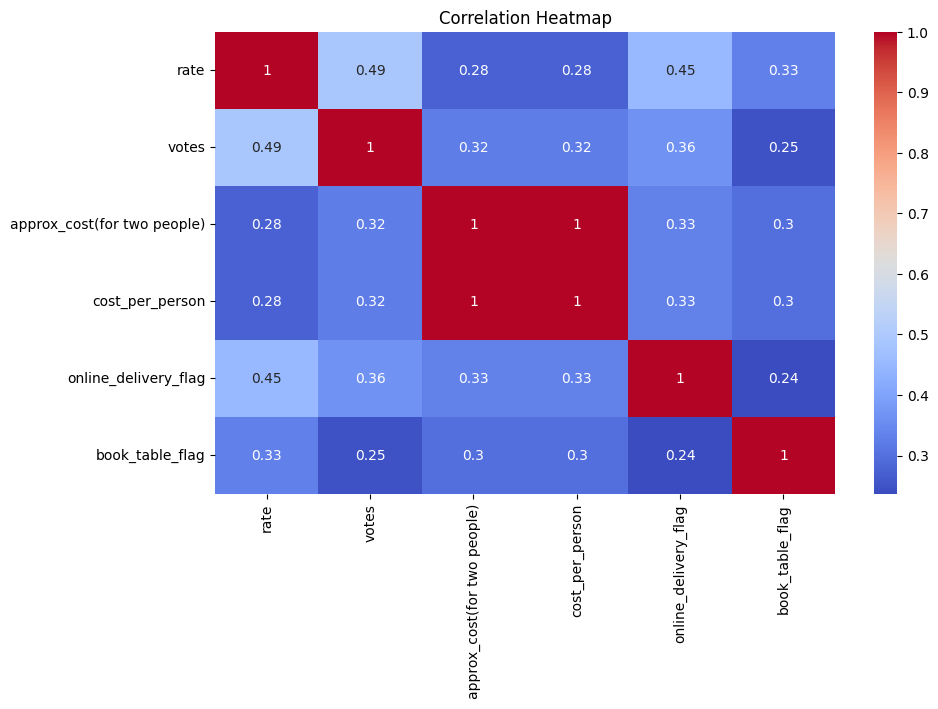

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features
numeric_features = dataframe.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


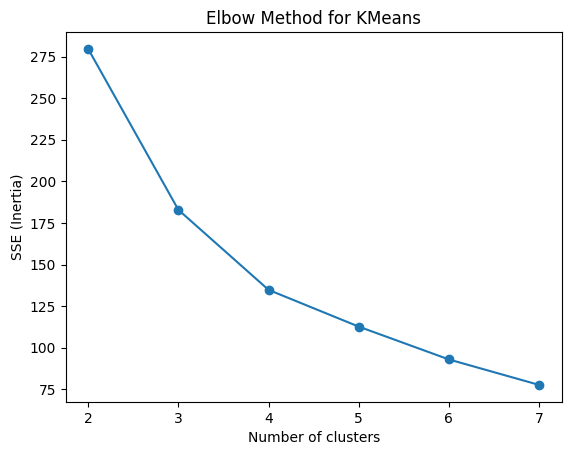

         cost_per_person      rate        votes
cluster                                        
0             323.958333  3.895833   407.312500
1             164.673913  3.167391    35.630435
2             318.750000  4.500000  3599.250000
3             131.000000  3.740000    72.100000


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Choose key features for clustering
features = dataframe[['cost_per_person','rate','votes']].dropna()

# Scale data
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Find optimal clusters using elbow method
sse = []
for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(2,8), sse, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for KMeans")
plt.show()

# Final clustering (say k=4)
kmeans = KMeans(n_clusters=4, random_state=42)
dataframe['cluster'] = kmeans.fit_predict(scaled)

# Cluster insights
print(dataframe.groupby('cluster')[['cost_per_person','rate','votes']].mean())
